# Bike Rental Prediction Project
**Author:** Ruba Sroor  
**Date:** 09/01/2026  

## Introduction
This notebook aims to predict bike rentals based on various features using machine learning models. 
We will perform data exploration, preprocessing, model training, hyperparameter tuning, and evaluate the best model.


### Step 1: Import Required Libraries
In this step, we import all the necessary Python libraries that will be used for data manipulation, visualization, preprocessing, model training, and evaluation.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

### Step 2: Load the Dataset
The dataset is loaded from a CSV file into a pandas DataFrame.


In [6]:
data = pd.read_csv('bike_rental_data.csv')

# EXPLARATARY DATA ANALYSIS (EDA)

### Step 3: Preview the Dataset
Display the first few rows of the dataset to understand its structure and features.


In [7]:
data.head()

,month,hour,weekday,weather,temperature,humidity,windspeed,rented_bikes
0,January,0,Saturday,Clear,9.84,81,0.0,16
1,January,1,Saturday,Clear,9.02,80,0.0,40
2,January,2,Saturday,Clear,9.02,80,0.0,32
3,January,3,Saturday,Clear,9.84,75,0.0,13
4,January,4,Saturday,Clear,9.84,75,0.0,1


### Step 4: Dataset Information
Check data types, number of entries, and detect missing values.


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8645 entries, 0 to 8644
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   month         8645 non-null   object 
 1   hour          8645 non-null   int64  
 2   weekday       8645 non-null   object 
 3   weather       8604 non-null   object 
 4   temperature   8522 non-null   float64
 5   humidity      8645 non-null   int64  
 6   windspeed     8477 non-null   float64
 7   rented_bikes  8645 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 540.4+ KB


### Step 5: Statistical Summary
View summary statistics for numerical features such as mean, standard deviation, and range.


In [9]:
data.describe()

,hour,temperature,humidity,windspeed,rented_bikes
count,8645.000000,8522.000000,8645.000000,8477.000000,8645.000000
mean,11.573626,20.037174,64.342973,12.808512,143.794448
std,6.907822,8.109607,19.629328,8.259934,133.797854
min,0.000000,0.820000,0.000000,0.000000,1.000000
25%,6.000000,13.120000,49.000000,7.001500,31.000000
50%,12.000000,20.500000,65.000000,12.998000,109.000000
75%,18.000000,27.060000,81.000000,19.001200,211.000000
max,23.000000,39.360000,100.000000,56.996900,651.000000


### Step 6: Analyze Categorical Features
Explore the distribution of categorical variables, such as weather conditions.


In [10]:
data["weather"].value_counts()

weather
Clear    5614
Mist     2212
Snow      777
Rain        1
Name: count, dtype: int64

### Step 7: Data Visualization
Visualize the distribution of numerical features using histograms.


array([[<Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'temperature'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'windspeed'}>],
       [<Axes: title={'center': 'rented_bikes'}>, <Axes: >]], dtype=object)

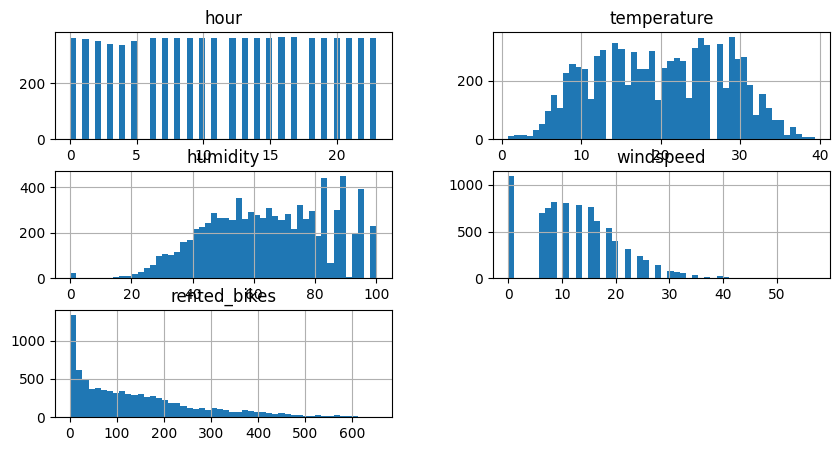

In [11]:
data.hist(bins=50, figsize=(10, 5))

# PREPARE THE DATA FOR ML ALGORITHMS

### Step 8: Split the Dataset
Split the dataset into training and testing sets to evaluate model performance on unseen data.


In [12]:
train_set, test_set = train_test_split(data, test_size=0.3, random_state=25)

### Step 9: Define Features and Target Variable
Separate the input features (X) from the target variable (y).


In [13]:
# the Features
x= train_set.drop("rented_bikes", axis=1) 
# the target
y= train_set["rented_bikes"].copy() 
print('Attributes are :\n',list(x.columns))

Attributes are :
 ['month', 'hour', 'weekday', 'weather', 'temperature', 'humidity', 'windspeed']


### Step 10: Create Preprocessing Pipelines
Define preprocessing steps for numerical and categorical features including missing value handling and scaling.


In [14]:
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy="median"),StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"),OneHotEncoder(handle_unknown="ignore"))

### Step 11: Combine Preprocessing Steps
Apply different preprocessing pipelines to numerical and categorical columns using a column transformer.


In [15]:
from sklearn.compose import make_column_selector, make_column_transformer
preprocessing = make_column_transformer((num_pipeline, make_column_selector(dtype_include=np.number)),
                                        (cat_pipeline, make_column_selector(dtype_include=object)),)

# Data training on models : 
- linear model (Linear Regression, Ridge)
- nonlinear model (Random Forest, XGBoost)
- Artificial Neural Network (MLPRegressor)

## Linear model: 
## Linear Regression Model
### Step 12: Train Linear Regression Model
Train a Linear Regression model and evaluate its performance using cross-validation.


In [16]:
from sklearn.linear_model import LinearRegression
lin_reg = make_pipeline(preprocessing,LinearRegression())
lin_reg.fit(x,y)
lin_rmses = -cross_val_score(lin_reg, x,y,scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count     10.000000
mean     104.431904
std        5.948527
min       90.776121
25%      101.744687
50%      105.073122
75%      109.077347
max      110.774456
dtype: float64

### Step 13: Tune Linear Regression Model
Use GridSearchCV to tune the Linear Regression model and find the best parameters.


In [36]:
lin_param_grid = {}
lin_grid_search = GridSearchCV(lin_reg, lin_param_grid , scoring="neg_root_mean_squared_error" ,cv=10)
lin_grid_search.fit(x, y)
print("Best RF RMSE after GridSearch:", -lin_grid_search.best_score_)
print("Best Params:", lin_grid_search.best_params_)

Best RF RMSE after GridSearch: 104.43190434764804
Best Params: {}


## Ridge Regression Model
### Step 14: Train Ridge Regression Model
Train a Ridge Regression model and evaluate it using cross-validation.


In [20]:
from sklearn.linear_model import Ridge
ridge_reg = make_pipeline(preprocessing,Ridge())
ridge_reg_rmses = -cross_val_score(ridge_reg, x,y,scoring="neg_root_mean_squared_error", cv=10)
pd.Series(ridge_reg_rmses).describe()

count     10.000000
mean     104.431115
std        5.948338
min       90.774400
25%      101.746718
50%      105.070224
75%      109.075639
max      110.774805
dtype: float64

### Step 15: Tune Ridge Model
Apply GridSearchCV to find the optimal hyperparameters for the Ridge model.


In [35]:
ridge_reg_pipe = make_pipeline(preprocessing,Ridge())
ridge_param_grid = {'ridge__alpha': [0.1, 1, 10]}
ridge_grid_search = GridSearchCV(ridge_reg_pipe, ridge_param_grid  ,scoring="neg_root_mean_squared_error", cv=10)
ridge_grid_search.fit(x, y)
print("Best RF RMSE after GridSearch:", -ridge_grid_search.best_score_)
print("Best Params:", ridge_grid_search.best_params_)

Best RF RMSE after GridSearch: 104.42709254731105
Best Params: {'ridge__alpha': 10}


## Random Forest Model
### Step 16: Train Random Forest Model
Train a Random Forest Regressor and evaluate its performance using cross-validation.


In [22]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = make_pipeline(preprocessing,RandomForestRegressor(random_state=25))
forest_rmses = -cross_val_score(forest_reg, x, y,scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

count    10.000000
mean     42.961157
std       3.063586
min      37.252092
25%      41.764411
50%      42.615316
75%      44.772398
max      48.538677
dtype: float64

### Step 17: Tune Random Forest Model
Apply GridSearchCV to find the optimal hyperparameters for the Random Forest model.


In [23]:
forest_reg_pipe = make_pipeline(preprocessing, RandomForestRegressor(random_state=25))
param_grid = [    {
        'randomforestregressor__n_estimators': [30, 100, 200],'randomforestregressor__max_features': [4, 6, 8, 10]},
        {'randomforestregressor__bootstrap': [False],'randomforestregressor__n_estimators': [10, 30],'randomforestregressor__max_features': [3, 4, 6]}]
grid_search = GridSearchCV(forest_reg_pipe, param_grid, cv=10, scoring='neg_root_mean_squared_error')
grid_search.fit(x, y)
print("Best RF RMSE after GridSearch:", -grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Best RF RMSE after GridSearch: 47.75074358311967
Best Params: {'randomforestregressor__max_features': 10, 'randomforestregressor__n_estimators': 200}


## XGBoost Model
### Step 18: Train XGBoost Model
Train an XGBoost Regressor and evaluate its performance using cross-validation.


In [24]:
from xgboost import XGBRegressor
xgb_reg = make_pipeline(preprocessing,XGBRegressor(n_estimators=500, 
                                     learning_rate=0.05, 
                                     max_depth=6, 
                                     random_state=25))
xgb_scores = -cross_val_score(xgb_reg, x, y, scoring="neg_root_mean_squared_error", cv=10)

print("--- XGBoost Result ---")
print(f"Mean RMSE: {xgb_scores.mean():.2f}")

--- XGBoost Result ---
Mean RMSE: 39.52


### Step 19: Tune XGBoost Model
Perform hyperparameter tuning on the XGBoost model using GridSearchCV.


In [37]:
xgb_reg_pipe = make_pipeline(preprocessing, XGBRegressor(random_state=25))
xgb_param_grid = {'xgbregressor__n_estimators': [100, 300, 500],
                    'xgbregressor__learning_rate': [0.01, 0.05, 0.1],
                    'xgbregressor__max_depth': [3, 5, 7]}
xgb_grid_search = GridSearchCV(xgb_reg_pipe, xgb_param_grid, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_grid_search.fit(x, y)
print("Best XGB RMSE after GridSearch:", -xgb_grid_search.best_score_)
print("Best Params:", xgb_grid_search.best_params_)

Best XGB RMSE after GridSearch: 38.781172561645505
Best Params: {'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 7, 'xgbregressor__n_estimators': 500}


## Artificial Neural Network
### Step 20: Train Artificial Neural Network (ANN)
Train a Neural Network model (MLPRegressor) and evaluate its performance using cross-validation.


In [26]:
from sklearn.neural_network import MLPRegressor
ann_reg = make_pipeline(preprocessing, MLPRegressor(hidden_layer_sizes=(100, 50), 
                                                   activation='relu', 
                                                   solver='adam', 
                                                   max_iter=1000, 
                                                   random_state=25))
ann_rmses = -cross_val_score(ann_reg, x, y, scoring="neg_root_mean_squared_error", cv=10) 
print("--- ANN Results ---")
print("Mean RMSE:", ann_rmses.mean().round(2)) 

C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


--- ANN Results ---
Mean RMSE: 43.91


### Step 21: Tune ANN Model
Use GridSearchCV to tune the Artificial Neural Network and find the best architecture and parameters.


In [27]:
ann_reg_pipe = make_pipeline(preprocessing, MLPRegressor(max_iter=1000, random_state=25))
mlp_param_grid = {'mlpregressor__hidden_layer_sizes': [(100,), (100, 50), (50, 50)],
                    'mlpregressor__activation': ['relu', 'tanh'],
                    'mlpregressor__solver': ['adam', 'lbfgs']}
mlp_grid_search = GridSearchCV(ann_reg_pipe, mlp_param_grid, cv=10, scoring='neg_root_mean_squared_error', n_jobs=-1)
mlp_grid_search.fit(x, y)
print("Best MLP (ANN) RMSE after GridSearch:", -mlp_grid_search.best_score_)
print("Best Params:", mlp_grid_search.best_params_)

Best MLP (ANN) RMSE after GridSearch: 42.41442654881892
Best Params: {'mlpregressor__activation': 'relu', 'mlpregressor__hidden_layer_sizes': (50, 50), 'mlpregressor__solver': 'lbfgs'}


C:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [40]:
import joblib
joblib.dump(xgb_reg_pipe, "bike_sharing_model.pkl")

['bike_sharing_model.pkl']

## Evaluate the best model (XGBoost) on the Test Set
### Step 22: Final Model Evaluation on Test Set
Train the selected best model on the full training set and evaluate its performance on the test set.


In [30]:
from sklearn.metrics import mean_squared_error 
final_model = xgb_reg
final_model.fit(x,y)

X_test = test_set.drop("rented_bikes", axis=1)
y_test = test_set["rented_bikes"].copy()

y_pred = final_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", test_rmse)

Test RMSE: 37.76887495066622


# Extra code to show some relations

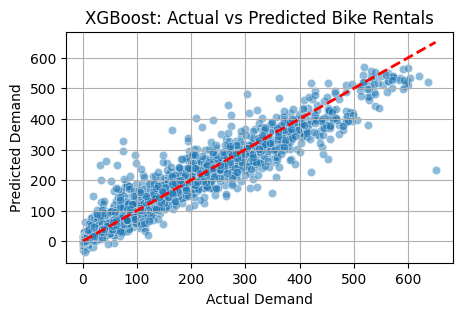

In [43]:
#extra code from AI To show how close the points are to the ideal line; the closer the points are to the line, the more accurate your model is.
import seaborn as sns
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('XGBoost: Actual vs Predicted Bike Rentals')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.grid(True)
plt.savefig('actual_vs_predicted.png', dpi=300) 
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_8148\3397898751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=rmse_values, palette='viridis')


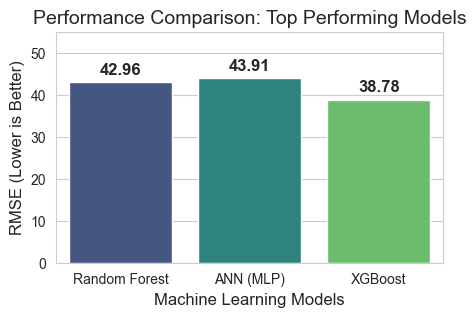

In [46]:
#extra code comparing the top 3 models, taken from AI
models = ['Random Forest', 'ANN (MLP)', 'XGBoost']
rmse_values = [42.96, 43.91, 38.78] 

plt.figure(figsize=(5, 3))
sns.set_style("whitegrid") 
ax = sns.barplot(x=models, y=rmse_values, palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Performance Comparison: Top Performing Models', fontsize=14)
plt.ylabel('RMSE (Lower is Better)', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylim(0, 55) 
plt.savefig('model_comparison.png', dpi=300)
plt.show()